mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, seaborn, pandas
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 0.8765 seconds
All requested packages already installed.
Dataset Shape: (244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


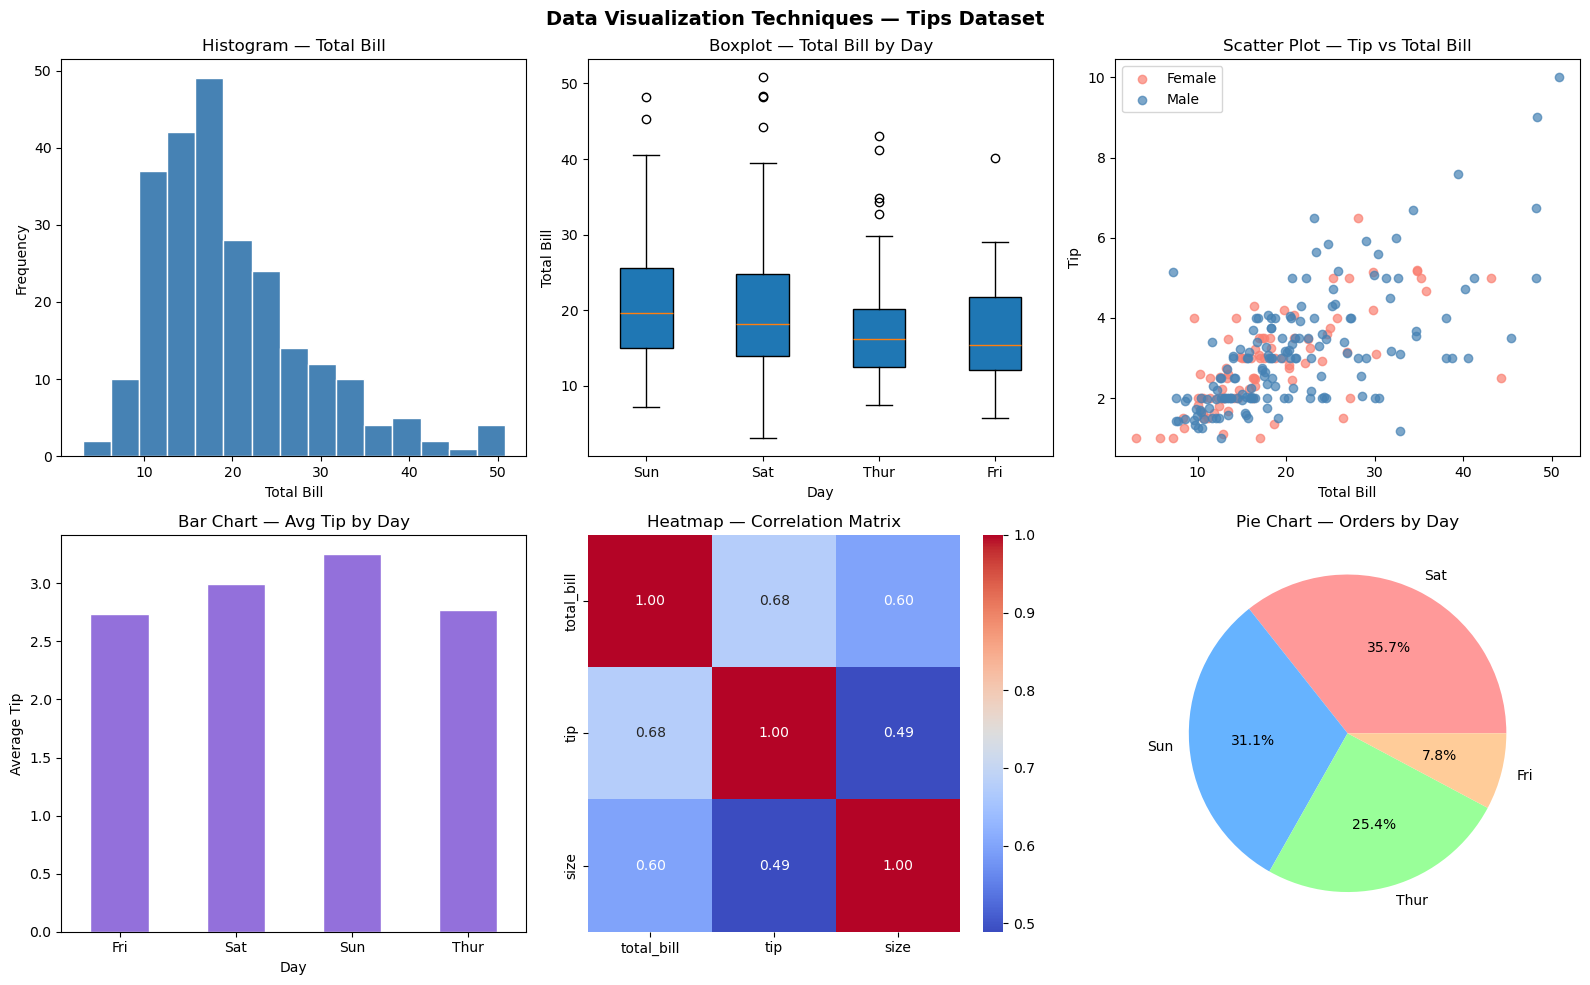

In [2]:
%matplotlib inline
!mamba install seaborn matplotlib pandas

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Exp4.csv')
print("Dataset Shape:", df.shape)
print(df.head())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Data Visualization Techniques — Tips Dataset', fontsize=14, fontweight='bold')

# 1. Histogram
axes[0, 0].hist(df['total_bill'], bins=15, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Histogram — Total Bill')
axes[0, 0].set_xlabel('Total Bill')
axes[0, 0].set_ylabel('Frequency')

# 2. Boxplot
axes[0, 1].boxplot([df[df['day'] == d]['total_bill'] for d in df['day'].unique()],
                   tick_labels=df['day'].unique(), patch_artist=True)
axes[0, 1].set_title('Boxplot — Total Bill by Day')
axes[0, 1].set_xlabel('Day')
axes[0, 1].set_ylabel('Total Bill')

# 3. Scatter Plot
colors = {'Male': 'steelblue', 'Female': 'salmon'}
for sex, grp in df.groupby('sex'):
    axes[0, 2].scatter(grp['total_bill'], grp['tip'], label=sex,
                       color=colors[sex], alpha=0.7)
axes[0, 2].set_title('Scatter Plot — Tip vs Total Bill')
axes[0, 2].set_xlabel('Total Bill')
axes[0, 2].set_ylabel('Tip')
axes[0, 2].legend()

# 4. Bar Chart
df.groupby('day')['tip'].mean().plot(kind='bar', ax=axes[1, 0],
                                     color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('Bar Chart — Avg Tip by Day')
axes[1, 0].set_xlabel('Day')
axes[1, 0].set_ylabel('Average Tip')
axes[1, 0].tick_params(axis='x', rotation=0)

# 5. Heatmap (correlation)
corr = df[['total_bill', 'tip', 'size']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1])
axes[1, 1].set_title('Heatmap — Correlation Matrix')

# 6. Pie Chart
df['day'].value_counts().plot(kind='pie', ax=axes[1, 2], autopct='%1.1f%%',
                               colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])
axes[1, 2].set_title('Pie Chart — Orders by Day')
axes[1, 2].set_ylabel('')

plt.tight_layout()
plt.show()